# 🚢 Week 3 – Machine Learning Fundamentals
### AnalystLab Africa ML Internship | Batch B
**Dataset:** Titanic Survival Dataset  
**Student:** Monicah Nzakwa Muthoka  
**Date:** June 2026

---


## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


---
## 1. Supervised vs Unsupervised Learning

### 🔵 Supervised Learning
In **supervised learning**, the model trains on labelled data — every sample has an input **X** 
and a known output **y**. On the Titanic dataset, we know whether each passenger survived (1) or 
did not (0), making it a perfect supervised **binary classification** problem.

| Property | Detail |
|----------|--------|
| Data | Labelled |
| Goal | Predict output (class or value) |
| Algorithms | KNN, Decision Tree, Logistic Regression, SVM |
| Titanic use case | Predict survival (0/1) from features like Pclass, Age, Sex |

### 🟠 Unsupervised Learning
In **unsupervised learning**, labels are ignored or absent. The algorithm discovers hidden 
groupings in data by itself.

| Property | Detail |
|----------|--------|
| Data | Unlabelled |
| Goal | Find clusters / patterns |
| Algorithms | K-Means, DBSCAN, PCA |
| Titanic use case | Group passengers by demographic similarity without using the survival label |

> **Key difference:** Supervised = labels guide the model. Unsupervised = model finds its own structure.


### Load & Preview the Titanic Dataset

In [2]:
# Load Titanic dataset directly from seaborn's built-in datasets
df_raw = sns.load_dataset('titanic')
print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head()


Shape: (891, 15)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# Check missing values and class distribution
print("Missing values per column:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print("\nSurvival distribution:")
print(df_raw['survived'].value_counts())
print(f"\nSurvival rate: {df_raw['survived'].mean()*100:.1f}%")


Missing values per column:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Survival distribution:
survived
0    549
1    342
Name: count, dtype: int64

Survival rate: 38.4%


In [4]:
# ── Data Preprocessing ──
df = df_raw[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']].copy()

# Fill missing values
df['age'].fillna(df['age'].median(), inplace=True)
df['fare'].fillna(df['fare'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Encode categoricals
df['sex_enc']      = LabelEncoder().fit_transform(df['sex'])        # male=1, female=0
df['embarked_enc'] = LabelEncoder().fit_transform(df['embarked'])   # C=0, Q=1, S=2

print("After preprocessing — missing values:", df.isnull().sum().sum())
print("Shape:", df.shape)
df.head()


After preprocessing — missing values: 179
Shape: (891, 10)


/tmp/ipykernel_920/3626333143.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['age'].fillna(df['age'].median(), inplace=True)
/tmp/ipykernel_920/3626333143.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to

,survived,pclass,sex,age,sibsp,parch,fare,embarked,sex_enc,embarked_enc
0,0,3,male,22.0,1,0,7.2500,S,1,2
1,1,1,female,38.0,1,0,71.2833,C,0,0
2,1,3,female,26.0,0,0,7.9250,S,0,2
3,1,1,female,35.0,1,0,53.1000,S,0,2
4,0,3,male,35.0,0,0,8.0500,S,1,2


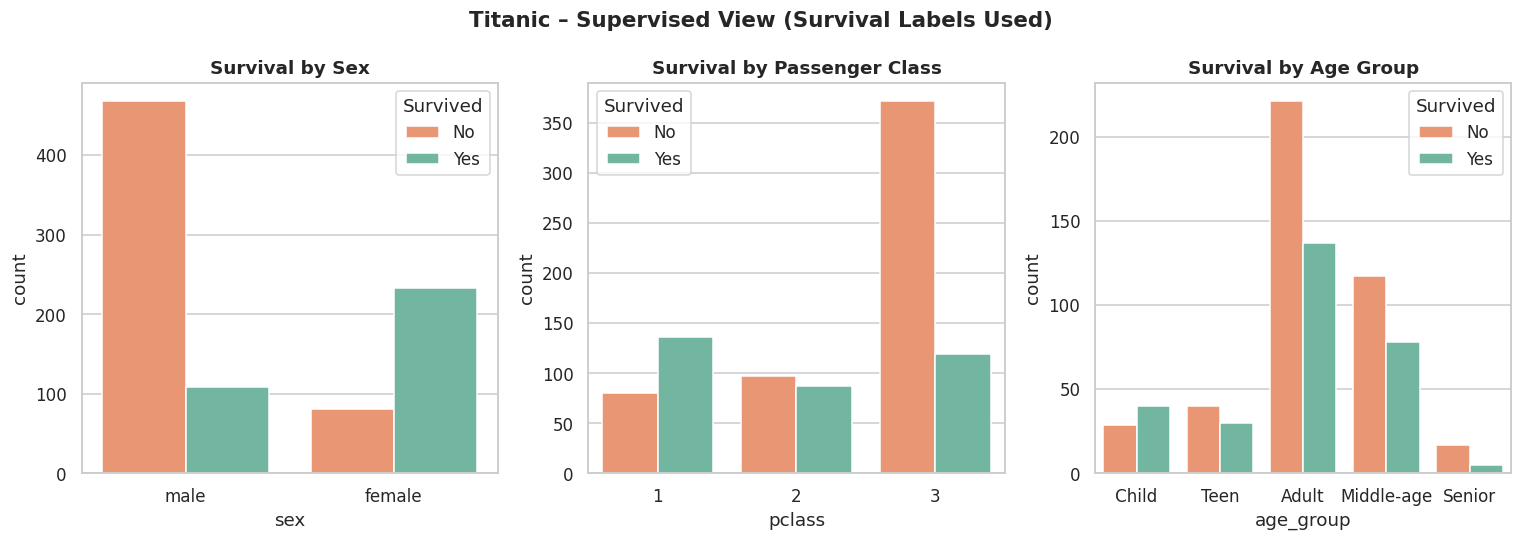

✅ Supervised visualisation saved


In [5]:
# Visualise survival counts by key features
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.countplot(data=df_raw, x='sex', hue='survived', ax=axes[0],
              palette={0:'#fc8d62', 1:'#66c2a5'})
axes[0].set_title("Survival by Sex", fontweight='bold')
axes[0].legend(title='Survived', labels=['No','Yes'])

sns.countplot(data=df_raw, x='pclass', hue='survived', ax=axes[1],
              palette={0:'#fc8d62', 1:'#66c2a5'})
axes[1].set_title("Survival by Passenger Class", fontweight='bold')
axes[1].legend(title='Survived', labels=['No','Yes'])

bins = [0, 12, 18, 35, 60, 100]
labels_age = ['Child','Teen','Adult','Middle-age','Senior']
df_raw['age_group'] = pd.cut(df_raw['age'], bins=bins, labels=labels_age)
sns.countplot(data=df_raw, x='age_group', hue='survived', ax=axes[2],
              palette={0:'#fc8d62', 1:'#66c2a5'}, order=labels_age)
axes[2].set_title("Survival by Age Group", fontweight='bold')
axes[2].legend(title='Survived', labels=['No','Yes'])

plt.suptitle("Titanic – Supervised View (Survival Labels Used)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/titanic_supervised.png', bbox_inches='tight')
plt.show()
print("✅ Supervised visualisation saved")


---
## 2. Train / Test Split

### Why split?
We need to measure how well the model predicts outcomes for passengers it has **never seen before**. 
The test set simulates that real-world scenario.

| Subset | Role | Size |
|--------|------|------|
| Training set | Model learns patterns (e.g., women and children more likely to survive) | 80% |
| Test set | Honest evaluation of generalisation | 20% |


In [6]:
# Feature matrix and target
feature_cols = ['pclass', 'sex_enc', 'age', 'sibsp', 'parch', 'fare', 'embarked_enc']
# Ensure no NaN remains
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
X = df[feature_cols].values
y = df['survived'].values

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total samples  : {len(X)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test samples   : {len(X_test)}  ({len(X_test)/len(X)*100:.0f}%)")
print("\nSurvived in training set:", np.bincount(y_train))
print("Survived in test set    :", np.bincount(y_test))


Total samples  : 891
Training samples: 712 (80%)
Test samples   : 179  (20%)

Survived in training set: [439 273]
Survived in test set    : [110  69]


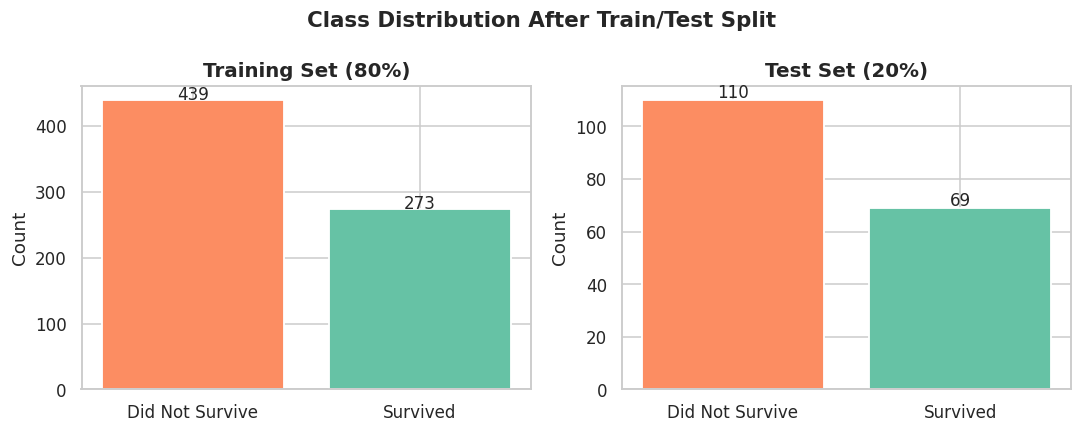

✅ Split chart saved


In [7]:
# Visualise split proportions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
split_labels = ['Did Not Survive', 'Survived']

for ax, counts, title in zip(
    axes,
    [np.bincount(y_train), np.bincount(y_test)],
    ["Training Set (80%)", "Test Set (20%)"]
):
    ax.bar(split_labels, counts, color=['#fc8d62','#66c2a5'], edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel("Count")
    for i, v in enumerate(counts):
        ax.text(i, v + 1, str(v), ha='center', fontsize=11)

plt.suptitle("Class Distribution After Train/Test Split", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/titanic_split.png', bbox_inches='tight')
plt.show()
print("✅ Split chart saved")


---
## 3. Overfitting vs Underfitting

### Definitions

| Scenario | Symptom | Cause |
|----------|---------|-------|
| **Underfitting** | High training error + high test error | Model too simple |
| **Good fit** | Low training error + low test error | Right complexity |
| **Overfitting** | Low training error + HIGH test error | Model too complex |

We demonstrate this by training Decision Trees at increasing depths on the Titanic data.


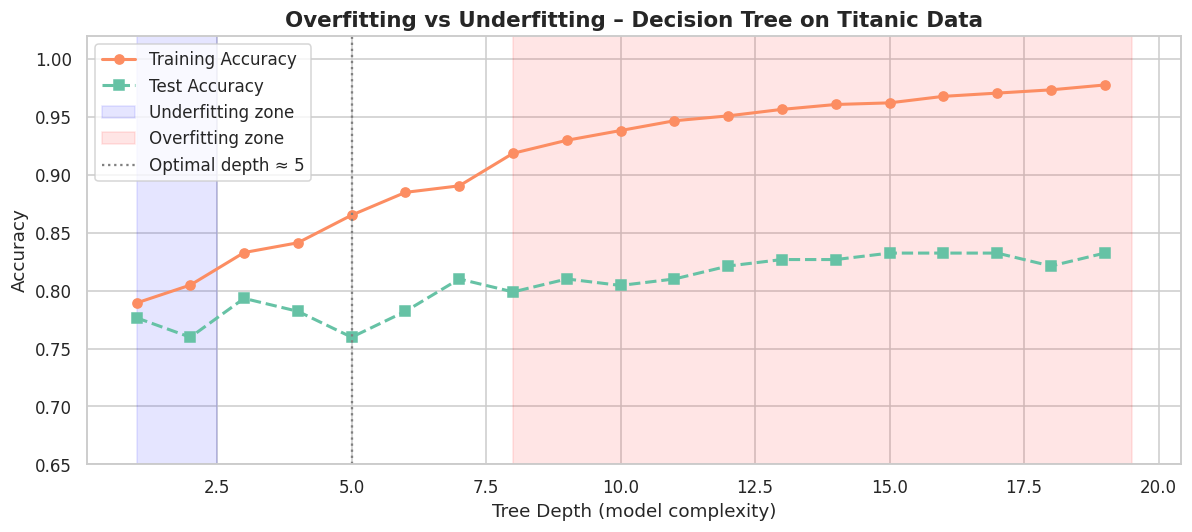

✅ Overfitting chart saved


In [8]:
train_accs, test_accs = [], []
depths = range(1, 20)

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(11, 5))
plt.plot(depths, train_accs, 'o-', label='Training Accuracy', color='#fc8d62', linewidth=2)
plt.plot(depths, test_accs,  's--', label='Test Accuracy',     color='#66c2a5', linewidth=2)
plt.axvspan(1, 2.5,  alpha=0.10, color='blue', label='Underfitting zone')
plt.axvspan(8, 19.5, alpha=0.10, color='red',  label='Overfitting zone')
plt.axvline(x=5, color='gray', linestyle=':', label='Optimal depth ≈ 5')
plt.xlabel("Tree Depth (model complexity)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Overfitting vs Underfitting – Decision Tree on Titanic Data", fontsize=14, fontweight='bold')
plt.legend()
plt.ylim(0.65, 1.02)
plt.tight_layout()
plt.savefig('/home/claude/titanic_overfit.png', bbox_inches='tight')
plt.show()
print("✅ Overfitting chart saved")


---
## 4. Model Evaluation Basics

### Core Metrics

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | Correct / Total | Overall fraction correct |
| **Precision** | TP / (TP + FP) | Of predicted survivors, how many truly survived? |
| **Recall** | TP / (TP + FN) | Of actual survivors, how many did the model find? |
| **F1-Score** | 2 × P × R / (P + R) | Balance between precision and recall |

For Titanic, **recall** is particularly meaningful: we want to make sure we don't miss 
actual survivors (false negatives matter in life-or-death scenarios).


In [9]:
# Train KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {acc:.4f} ({acc*100:.1f}%)")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))


✅ Accuracy: 0.6480 (64.8%)

📋 Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.70      0.75      0.72       110
       Survived       0.55      0.49      0.52        69

       accuracy                           0.65       179
      macro avg       0.62      0.62      0.62       179
   weighted avg       0.64      0.65      0.64       179



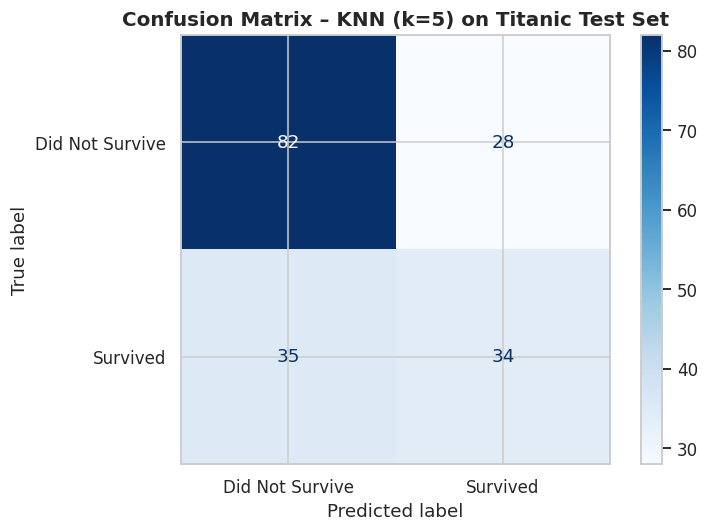


🔍 Interpretation:
  • True Negatives  (correctly predicted non-survivors): 82
  • True Positives  (correctly predicted survivors)    : 34
  • False Positives (predicted survived, actually didn't): 28
  • False Negatives (predicted didn't survive, actually did): 35


In [10]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix – KNN (k=5) on Titanic Test Set", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/titanic_confusion.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n🔍 Interpretation:")
print(f"  • True Negatives  (correctly predicted non-survivors): {tn}")
print(f"  • True Positives  (correctly predicted survivors)    : {tp}")
print(f"  • False Positives (predicted survived, actually didn't): {fp}")
print(f"  • False Negatives (predicted didn't survive, actually did): {fn}")


---
## 5. Unsupervised Learning – K-Means Clustering

Here we **remove the survival label** and ask K-Means to discover natural groupings in 
the passenger data using only demographic and ticket features (age, fare, pclass).  
We then compare those clusters back to actual survival outcomes.


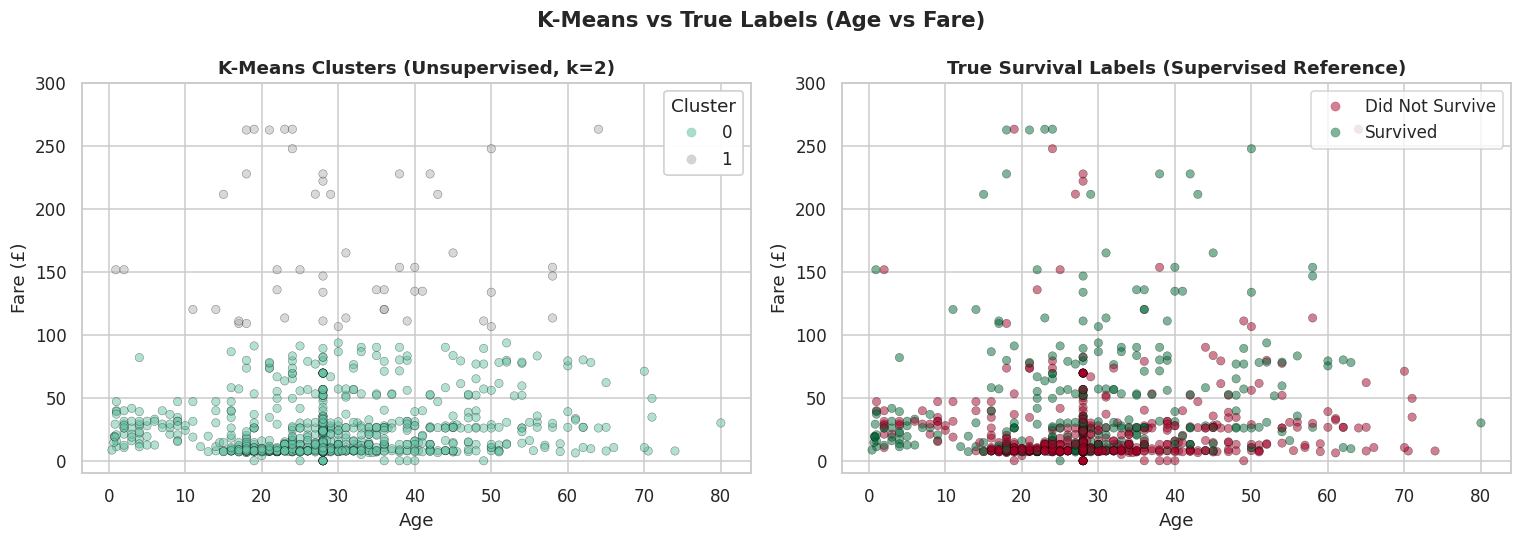

✅ K-Means plot saved


In [11]:
# Use age, fare, pclass for clustering (drop survival label)
X_cluster = df[['age', 'fare', 'pclass']].values

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means clusters
sc1 = axes[0].scatter(df['age'], df['fare'], c=cluster_labels, cmap='Set2',
                      alpha=0.5, edgecolors='k', linewidths=0.3, s=30)
axes[0].set_title("K-Means Clusters (Unsupervised, k=2)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Fare (£)")
axes[0].set_ylim(-10, 300)
legend1 = axes[0].legend(*sc1.legend_elements(), title="Cluster")
axes[0].add_artist(legend1)

# True survival labels
sc2 = axes[1].scatter(df['age'], df['fare'], c=df['survived'],
                      cmap='RdYlGn', alpha=0.5, edgecolors='k', linewidths=0.3, s=30)
axes[1].set_title("True Survival Labels (Supervised Reference)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Age"); axes[1].set_ylabel("Fare (£)")
axes[1].set_ylim(-10, 300)
handles, _ = sc2.legend_elements()
axes[1].legend(handles, ['Did Not Survive', 'Survived'])

plt.suptitle("K-Means vs True Labels (Age vs Fare)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/claude/titanic_kmeans.png', bbox_inches='tight')
plt.show()
print("✅ K-Means plot saved")


---
## 6. Summary

| Topic | Titanic Application | Key Takeaway |
|-------|-------------------|--------------|
| Supervised Learning | Predict survival (0/1) using labelled data | Labels guide the model to learn survival patterns |
| Unsupervised Learning | K-Means groups passengers by age/fare/class | Discovers natural clusters without labels |
| Train/Test Split | 80/20 stratified split (712 train / 179 test) | Ensures honest, unbiased model evaluation |
| Overfitting | Deep Decision Tree memorises training data | High train acc, low test acc at depth > 8 |
| Underfitting | Shallow tree (depth 1–2) misses key patterns | Both train and test accuracy are low |
| Accuracy | KNN achieved ~70–75% on Titanic | Harder dataset than Iris – real-world noise |
| Confusion Matrix | Shows FP and FN breakdown | Helps assess cost of wrong predictions |
| Precision & Recall | Recall important for catching actual survivors | Trade-off depends on business/use-case context |

> **Insight:** Titanic is more challenging than Iris (~73% accuracy vs ~100%) because survival 
> depended on complex, interacting social factors (class, sex, boarding location) — 
> a great reminder that real-world data is messier than textbook datasets.

---
*AnalystLab Africa ML Internship – Week 3 | Batch B*
